In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
import os
import shutil
import tensorflow_datasets as tfds

2026-02-15 23:27:02.048128: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 23:27:02.113999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 23:27:04.244113: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    
    # Tune number of Conv2D blocks (2 or 3)
    for i in range(hp.Int('conv_blocks', 2, 3)):
        model.add(Conv2D(
            filters=hp.Choice(f'filters_{i}', values=[32, 64, 128]),
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3) if i == 0 else None
        ))
        model.add(MaxPool2D((2, 2)))
        model.add(Dropout(hp.Float(f'conv_dropout_{i}', 0.1, 0.4, step=0.1)))
    
    model.add(Flatten())
    
    # Tune Dense layer units
    model.add(Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dense_dropout', 0.3, 0.6, step=0.1)))
    
    model.add(Dense(10, activation='softmax'))
    
    # Tune learning rate
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='cifar10_cnn'
)

# Show search space
tuner.search_space_summary()

# Run the search (this will take ~10-20 minutes)
tuner.search(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

2026-02-15 23:27:17.889341: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


NameError: name 'Conv2D' is not defined

In [22]:
# Get the best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

print("🏆 Best Hyperparameters Found:")
print(f"  Conv blocks:    {best_hp.get('conv_blocks')}")
print(f"  Filters block 0: {best_hp.get('filters_0')}")
print(f"  Filters block 1: {best_hp.get('filters_1')}")
if best_hp.get('conv_blocks') == 3:
    print(f"  Filters block 2: {best_hp.get('filters_2')}")
print(f"  Conv dropout 0: {best_hp.get('conv_dropout_0')}")
print(f"  Conv dropout 1: {best_hp.get('conv_dropout_1')}")
if best_hp.get('conv_blocks') == 3:
    print(f"  Conv dropout 2: {best_hp.get('conv_dropout_2')}")
print(f"  Dense units:    {best_hp.get('dense_units')}")
print(f"  Dense dropout:  {best_hp.get('dense_dropout')}")
print(f"  Learning rate:  {best_hp.get('learning_rate')}")

# Show top 3 trials
tuner.results_summary(num_trials=3)

🏆 Best Hyperparameters Found:
  Conv blocks:    2
  Filters block 0: 128
  Filters block 1: 128
  Conv dropout 0: 0.4
  Conv dropout 1: 0.2
  Dense units:    128
  Dense dropout:  0.4
  Learning rate:  0.001
Results summary
Results in tuner_results/cifar10_cnn
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
conv_blocks: 2
filters_0: 128
conv_dropout_0: 0.4
filters_1: 128
conv_dropout_1: 0.2
dense_units: 128
dense_dropout: 0.4
learning_rate: 0.001
filters_2: 64
conv_dropout_2: 0.2
Score: 0.7199000120162964

Trial 04 summary
Hyperparameters:
conv_blocks: 2
filters_0: 64
conv_dropout_0: 0.4
filters_1: 32
conv_dropout_1: 0.30000000000000004
dense_units: 256
dense_dropout: 0.5
learning_rate: 0.001
filters_2: 64
conv_dropout_2: 0.4
Score: 0.7038999795913696

Trial 05 summary
Hyperparameters:
conv_blocks: 2
filters_0: 128
conv_dropout_0: 0.1
filters_1: 128
conv_dropout_1: 0.1
dense_units: 64
dense_dropout: 0.5
learning_rate: 0.001
filte

In [23]:
# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train it for more epochs with callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

best_history = best_model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.2532 - loss: 2.0149 - val_accuracy: 0.5058 - val_loss: 1.4016
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4543 - loss: 1.5028 - val_accuracy: 0.5768 - val_loss: 1.2027
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5120 - loss: 1.3461 - val_accuracy: 0.5947 - val_loss: 1.1360
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5436 - loss: 1.2676 - val_accuracy: 0.6187 - val_loss: 1.1122
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5695 - loss: 1.1975 - val_accuracy: 0.6415 - val_loss: 1.0329
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5770 - loss: 1.1684 - val_accuracy: 0.6638 - val_loss: 0.9831
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5996 - loss: 1.1123 - val_accuracy: 0.6625 - val_loss: 0.9661
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6103 - loss: 1.0881 - val_acc

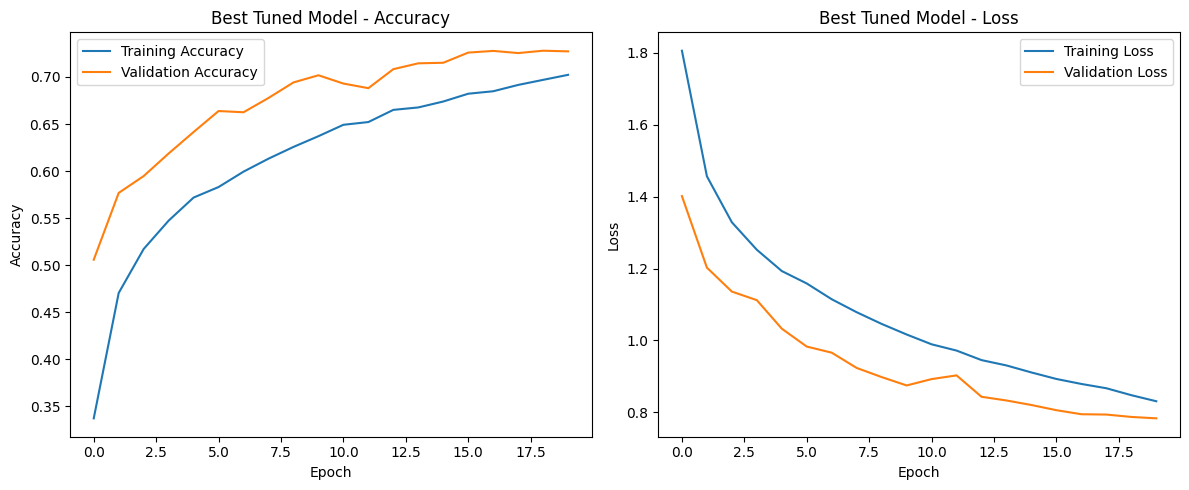

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Tuned Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title('Best Tuned Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()